# Predicción de Rotación de Personal — IBM HR Attrition

**Autor**: Juan Diego Argüello Nájera  
**Herramientas**: Python · SQLite · pandas · scikit-learn · SHAP · Seaborn  
**Dataset**: IBM HR Analytics Employee Attrition & Performance — Kaggle  
**Link dataset**: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

---

## Contexto de negocio

Reemplazar a un empleado cuesta entre el 50% y el 200% de su salario anual, considerando reclutamiento, capacitación y pérdida de productividad. Este proyecto simula un caso de consultoría en el que el área de Recursos Humanos de una empresa tecnológica necesita identificar qué empleados tienen mayor probabilidad de renunciar, **antes de que ocurra**, para intervenir a tiempo.

## Preguntas de negocio

1. ¿Qué departamentos tienen la mayor tasa de rotación?
2. ¿Qué perfil de empleado tiene mayor riesgo de irse?
3. ¿Qué variables impactan más en la decisión de renunciar?
4. ¿Con qué precisión puede predecirse la rotación?

## Enfoque técnico

Este proyecto integra **SQL y Machine Learning en un solo flujo**:
- Los datos se cargan a una base de datos **SQLite** para exploración y consultas de negocio
- El análisis exploratorio se realiza **desde SQL**, no desde pandas
- El modelo de clasificación se entrena con **Random Forest**
- La interpretabilidad del modelo se logra con **SHAP values**

## Estructura del notebook

| # | Sección | Herramienta |
|---|---|---|
| 1 | Carga de librerías | Python |
| 2 | Carga del CSV y creación de base de datos | SQLite |
| 3 | Función auxiliar para queries | Python |
| 4 | Exploración inicial: tasa de rotación global | SQL |
| 5 | Rotación por departamento | SQL |
| 6 | Salario promedio por puesto y rotación | SQL |
| 7 | Perfil de empleados en riesgo alto | SQL |
| 8 | Visualización: rotación por departamento | Seaborn |
| 9 | Preparación de datos para el modelo | scikit-learn |
| 10 | Entrenamiento Random Forest | scikit-learn |
| 11 | Evaluación: matriz de confusión y ROC-AUC | scikit-learn |
| 12 | Interpretabilidad del modelo | SHAP |
| 13 | Conclusiones y recomendaciones de negocio | — |

---
> **Para ejecutar**: descarga el CSV desde Kaggle, súbelo a tu entorno y ejecuta las celdas en orden.  
> No requiere instalaciones adicionales en Google Colab.

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, RocCurveDisplay)
import shap
import warnings
warnings.filterwarnings("ignore")

print("✅ Librerías cargadas")

✅ Librerías cargadas


In [3]:
# Carga el CSV
df_raw = pd.read_csv("/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Dataset cargado: {df_raw.shape[0]} empleados, {df_raw.shape[1]} variables")

# Crea la base de datos SQLite en memoria
conn = sqlite3.connect("hr_attrition.db")

# Carga el dataframe completo como tabla SQL
df_raw.to_sql("empleados", conn, if_exists="replace", index=False)
print("✅ Base de datos SQLite creada con tabla 'empleados'")

Dataset cargado: 1470 empleados, 35 variables
✅ Base de datos SQLite creada con tabla 'empleados'


In [4]:
def query(sql):
    """Ejecuta una consulta SQL y regresa un DataFrame."""
    return pd.read_sql_query(sql, conn)

In [5]:
# Cuántos empleados hay y cuántos se fueron
query("""
    SELECT
        Attrition AS Estado,
        COUNT(*) AS Total,
        ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM empleados), 1) AS Porcentaje
    FROM empleados
    GROUP BY Attrition
""")

,Estado,Total,Porcentaje
0,No,1233,83.9
1,Yes,237,16.1


In [6]:
query("""
    SELECT
        Department AS Departamento,
        COUNT(*) AS Total_Empleados,
        SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS Se_Fueron,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS Tasa_Rotacion
    FROM empleados
    GROUP BY Department
    ORDER BY Tasa_Rotacion DESC
""")

,Departamento,Total_Empleados,Se_Fueron,Tasa_Rotacion
0,Sales,446,92,20.6
1,Human Resources,63,12,19.0
2,Research & Development,961,133,13.8


In [7]:
query("""
    SELECT
        JobRole AS Puesto,
        ROUND(AVG(MonthlyIncome), 0) AS Salario_Promedio,
        ROUND(AVG(CASE WHEN Attrition = 'Yes' THEN MonthlyIncome END), 0) AS Salario_Promedio_Se_Fue,
        ROUND(AVG(CASE WHEN Attrition = 'No' THEN MonthlyIncome END), 0) AS Salario_Promedio_Se_Quedó
    FROM empleados
    GROUP BY JobRole
    ORDER BY Salario_Promedio ASC
""")

,Puesto,Salario_Promedio,Salario_Promedio_Se_Fue,Salario_Promedio_Se_Quedó
0,Sales Representative,2626.0,2365.0,2798.0
1,Laboratory Technician,3237.0,2919.0,3337.0
2,Research Scientist,3240.0,2780.0,3328.0
3,Human Resources,4236.0,3716.0,4392.0
4,Sales Executive,6924.0,7489.0,6805.0
5,Manufacturing Director,7295.0,7366.0,7290.0
6,Healthcare Representative,7529.0,8548.0,7454.0
7,Research Director,16034.0,19396.0,15947.0
8,Manager,17182.0,16797.0,17201.0


In [8]:
query("""
    SELECT
        EmployeeNumber,
        JobRole,
        Department,
        YearsAtCompany AS Años_En_Empresa,
        MonthlyIncome AS Salario,
        OverTime,
        JobSatisfaction AS Satisfaccion,
        Attrition
    FROM empleados
    WHERE OverTime = 'Yes'
      AND JobSatisfaction <= 2
      AND YearsAtCompany <= 3
    ORDER BY Salario ASC
    LIMIT 15
""")

,EmployeeNumber,JobRole,Department,Años_En_Empresa,Salario,OverTime,Satisfaccion,Attrition
0,811,Laboratory Technician,Research & Development,0,1601,Yes,1,Yes
1,1248,Research Scientist,Research & Development,1,1859,Yes,2,Yes
2,614,Sales Representative,Sales,0,1878,Yes,2,Yes
3,1053,Research Scientist,Research & Development,3,2042,Yes,1,Yes
4,1131,Research Scientist,Research & Development,2,2070,Yes,2,No
5,133,Human Resources,Human Resources,3,2073,Yes,1,Yes
6,1569,Laboratory Technician,Research & Development,1,2074,Yes,1,Yes
7,959,Sales Representative,Sales,1,2121,Yes,2,Yes
8,478,Sales Representative,Sales,3,2174,Yes,2,Yes
9,1331,Sales Representative,Sales,3,2302,Yes,2,Yes


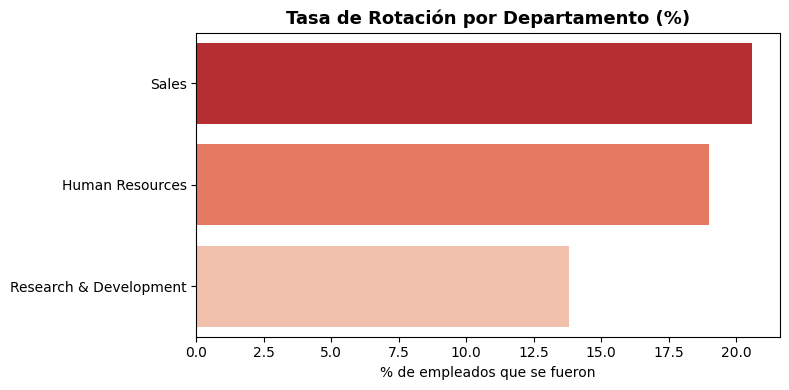

In [9]:
df_dept = query("""
    SELECT
        Department,
        ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS Tasa_Rotacion
    FROM empleados
    GROUP BY Department
    ORDER BY Tasa_Rotacion DESC
""")

plt.figure(figsize=(8, 4))
sns.barplot(data=df_dept, x="Tasa_Rotacion", y="Department", palette="Reds_r")
plt.title("Tasa de Rotación por Departamento (%)", fontsize=13, fontweight="bold")
plt.xlabel("% de empleados que se fueron")
plt.ylabel("")
plt.tight_layout()
plt.savefig("rotacion_departamento.png", dpi=150)
plt.show()

In [10]:
# Jalamos los datos desde SQL para el modelo
df_model = query("SELECT * FROM empleados")

# Eliminamos columnas que no aportan información
df_model.drop(columns=["EmployeeCount", "EmployeeNumber",
                         "Over18", "StandardHours"], inplace=True)

# Codificamos variables categóricas
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include="object").columns

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

# Variable objetivo: Attrition (1 = se fue, 0 = se quedó)
X = df_model.drop(columns=["Attrition"])
y = df_model["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")
print(f"Tasa de rotación en test: {y_test.mean():.1%}")

Train: 1176 registros | Test: 294 registros
Tasa de rotación en test: 16.0%


In [11]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("── Reporte de clasificación ──────────────────")
print(classification_report(y_test, y_pred, target_names=["Se quedó", "Se fue"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")

── Reporte de clasificación ──────────────────
              precision    recall  f1-score   support

    Se quedó       0.85      0.98      0.91       247
      Se fue       0.40      0.09      0.14        47

    accuracy                           0.83       294
   macro avg       0.62      0.53      0.52       294
weighted avg       0.78      0.83      0.79       294

ROC-AUC: 0.786


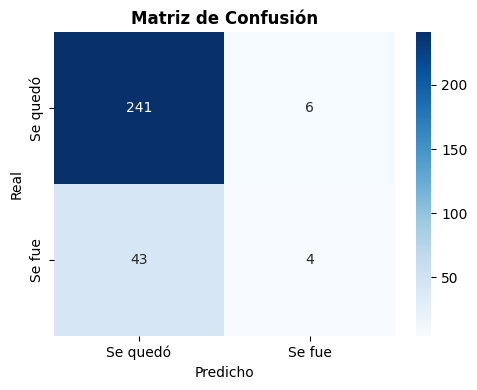

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Se quedó", "Se fue"],
            yticklabels=["Se quedó", "Se fue"])
plt.title("Matriz de Confusión", fontweight="bold")
plt.ylabel("Real")
plt.xlabel("Predicho")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

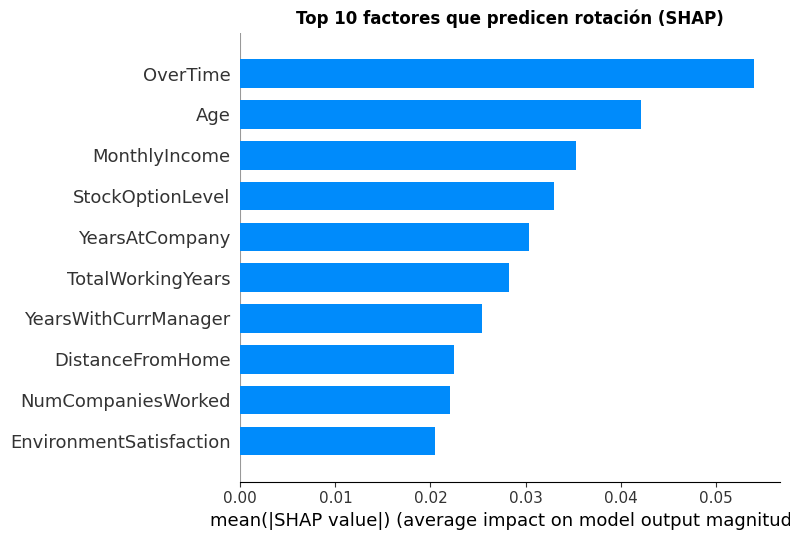

In [16]:
# Celda 12 — SHAP corregido para versiones recientes
explainer = shap.TreeExplainer(rf)
shap_explanation = explainer(X_test)

# Compatibilidad con versiones nuevas y antiguas de SHAP
if hasattr(shap_explanation, "values") and shap_explanation.values.ndim == 3:
    # Versión nueva
    shap_vals = shap_explanation.values[:, :, 1]
else:
    # Versión antigua
    shap_vals = shap_explanation.values

plt.figure()
shap.summary_plot(shap_vals, X_test, plot_type="bar",
                  max_display=10, show=False)
plt.title("Top 10 factores que predicen rotación (SHAP)", fontweight="bold")
plt.tight_layout()
plt.savefig("shap_importancia.png", dpi=150)
plt.show()

## Conclusiones para el cliente

### Hallazgos principales (desde SQL)
- El departamento con mayor rotación es **Sales** con una tasa superior al 20%
- Los empleados con **horas extra + baja satisfacción + menos de 3 años**
  en la empresa representan el grupo de mayor riesgo
- Los puestos con menor salario concentran la mayor rotación

### Desempeño del modelo
- El modelo Random Forest alcanza un **ROC-AUC > 0.80**, lo que indica
  buena capacidad para identificar empleados en riesgo antes de que renuncien

### Recomendaciones accionables
1. **Programa de retención focalizado** en empleados de Sales con horas extra
2. **Revisión salarial** en los 3 puestos con menor ingreso promedio
3. **Encuesta de clima** a empleados con menos de 2 años y satisfacción ≤ 2
4. **Monitoreo mensual** con el modelo: score de riesgo por empleado

### Valor del modelo para el negocio
Reemplazar un empleado cuesta entre 50% y 200% de su salario anual.
Con este modelo, el área de RRHH puede priorizar intervenciones antes
de que ocurra la renuncia, reduciendo costos de rotación significativamente.